Found 535 images belonging to 2 classes.
Found 133 images belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,697,345 (21.73 MB)

 Trainable params: 5,697,345 (21.73 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4772 - loss: 0.7720 - val_accuracy: 0.7519 - val_loss: 0.5438
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 937ms/step - accuracy: 0.7389 - loss: 0.5429 - val_accuracy: 0.7519 - val_loss: 0.5898
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 918ms/step - accuracy: 0.7493 - loss: 0.4414 - val_accuracy: 0.7519 - val_loss: 0.5960
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7615 - loss: 0.3948 - val_accuracy: 0.7895 - val_loss: 0.5110
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8123 - loss: 0.3558 - val_accuracy: 0.7068 - val_loss: 0.5531
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8218 - loss: 0.3317 - val_accuracy: 0.7444 - val_loss: 0.5360
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8497 - loss: 0.3307 - val_accuracy: 0.8722 - val_loss: 0.3589
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8971 - loss: 0.2149 - val_accuracy: 0.9173 - val_loss: 0.2641

Test Accuracy: 0.91


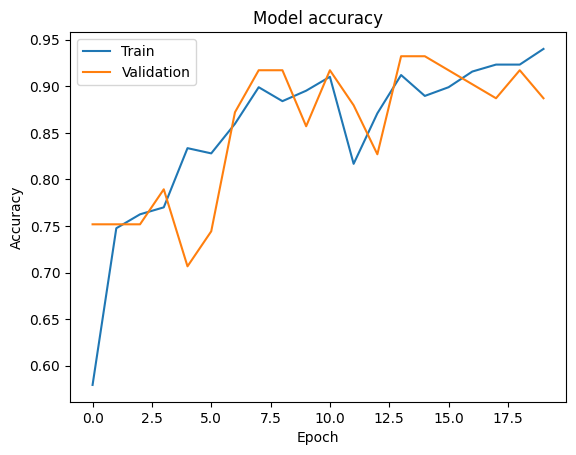

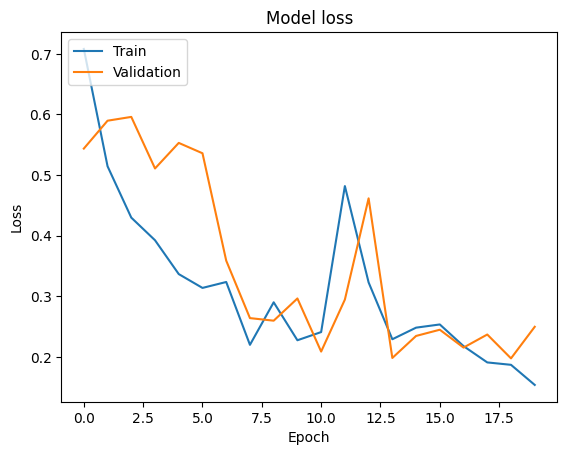

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Data Preprocessing with ImageDataGenerator

# Image Data Generator for Augmentation (on training set only)
train_datagen = ImageDataGenerator(rescale=1./255,  # Rescale pixel values between 0 and 1
                                   shear_range=0.2,  # Shearing
                                   zoom_range=0.2,   # Random zoom
                                   horizontal_flip=True,  # Horizontal flip
                                   validation_split=0.2)  # Split for validation

test_datagen = ImageDataGenerator(rescale=1./255)  # Rescale only for testing/validation

basePath = './'

# Load Training and Validation Data
train_generator = train_datagen.flow_from_directory(
    '{}train'.format(basePath),  # Path to training dataset
    target_size=(180, 180),  # Resize images to 150x150
    batch_size=60,
    class_mode='binary',  # Binary classification (TB vs Normal)
    subset='training')

validation_generator = train_datagen.flow_from_directory(
    '{}train'.format(basePath),  # Path to training dataset
    target_size=(180, 180),
    batch_size=60,
    class_mode='binary',
    subset='validation')

# Step 2: Build the CNN Model

model = Sequential()

# Convolutional Layer 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)))  # 32 filters, 3x3 kernel
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))  # 64 filters
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))  # 128 filters
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 4
model.add(Conv2D(256, (3, 3), activation='elu'))  # 128 filters
model.add(MaxPooling2D(pool_size=(2, 2)))

# # Convolutional Layer 5
# model.add(Conv2D(512, (3, 3), activation='elu'))  # 128 filters
# model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected Layers
model.add(Flatten())  # Flatten the 3D output to 1D for Dense layer
model.add(Dense(256, activation='relu'))  # Fully connected layer
model.add(Dropout(0.5))  # Dropout for regularization
model.add(Dense(1, activation='sigmoid'))  # Output layer (binary classification)

# Check model property
print(model.summary())

# Step 3: Compile the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4: Train the CNN Model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stopping])

# Step 5: Evaluate the Model on Test Data
test_generator = test_datagen.flow_from_directory(
    '{}test'.format(basePath),
    target_size=(180, 180),
    batch_size=60,
    class_mode='binary') 

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc:.2f}')

model.save('TB_Detection_CNN.h5')
# Step 6: Predict on the Test Data
# y_pred_prob = model.predict(test_generator)  # Get probabilities
# y_pred = np.round(y_pred_prob).astype(int)   # Convert probabilities to binary (0 or 1)

# # Step 7: True Labels from Test Generator
# y_true = test_generator.classes  # Get true labels from test generator
# class_labels = list(test_generator.class_indices.keys())  # Get class names

# # Step 8: Classification Report
# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, target_names=class_labels))

# Step 9: Confusion Matrix
# cm = confusion_matrix(y_true, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the Confusion Matrix
# disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
# plt.title("Confusion Matrix")
# plt.show()

# Optional: Plot Training and Validation Loss/Accuracy Curves

# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
